In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
def make_diag_plots(bkg_axis,sig_axes,sample="XYY3000_Y170_Yp170",reducs=[],norm=False,decor=None):
    from sklearn.linear_model import LinearRegression

    from quakSpaceMaker import reductions
    sig_losses_bkg = []
    if norm:
        base = "lossEvals_normalized"
    else:
        base = "lossEvals"
    with h5py.File(f"{base}/BKG.h5","r") as f:
        mjj_bkg = f["mjj"][()]
        bkg_loss_bkg = f["BKG_mjjFlat"][()]
        for ax in sig_axes:
            sig_losses_bkg.append(f[ax][()].reshape(-1,1))
    sig_losses_bkg = np.concatenate(sig_losses_bkg,axis=1)

    sig_losses_sig = []
    with h5py.File(f"{base}/{sample}.h5","r") as f:
        bkg_loss_sig = f["BKG_mjjFlat"][()]
        mjj_sig = f["mjj"][()]
        for ax in sig_axes:
            sig_losses_sig.append(f[ax][()].reshape(-1,1))
    sig_losses_sig = np.concatenate(sig_losses_sig,axis=1)
    
    # convert to likelihood ratio
    for i in range(len(sig_axes)):
        sig_losses_bkg[:,i] -= bkg_loss_bkg
        sig_losses_sig[:,i] -= bkg_loss_sig
    
     # add big offset to get away from scary negatives
    sig_losses_bkg += 30
    sig_losses_sig += 30
    
    if decor:
        if decor == "linear":
            regs = {}
            reg_bkg = LinearRegression().fit(mjj_bkg.reshape(-1,1),bkg_loss_bkg.reshape(-1,1))
            bkg_loss_bkg = bkg_loss_bkg - reg_bkg.predict(mjj_bkg.reshape(-1,1))[:,0] + reg_bkg.intercept_
            bkg_loss_sig = bkg_loss_sig - reg_bkg.predict(mjj_sig.reshape(-1,1))[:,0] + reg_bkg.intercept_
            for i,ax in enumerate(sig_axes):
                regs[ax] = LinearRegression()
                regs[ax].fit(mjj_bkg.reshape(-1,1),sig_losses_bkg[:,i].reshape(-1,1))
                sig_losses_bkg[:,i] = sig_losses_bkg[:,i] - regs[ax].predict(mjj_bkg.reshape(-1,1))[:,0] + regs[ax].intercept_
                sig_losses_sig[:,i] = sig_losses_sig[:,i] - regs[ax].predict(mjj_sig.reshape(-1,1))[:,0] + regs[ax].intercept_
    
    reduc_losses_bkg = [reductions[r].transform(sig_losses_bkg).flatten() for r in reducs]
    reduc_losses_sig = [reductions[r].transform(sig_losses_sig).flatten() for r in reducs]

    plt.figure(figsize=(12,8))
    if norm:
        bins_loss = np.linspace(0,6,100)
        bins_reduc = np.linspace(0,5,100)
    else:
        bins_loss = np.linspace(-10,70,100)
        bins_reduc = np.linspace(10,50,100)

    plt.subplot(221)
    for i,ax in enumerate(sig_axes):
        h = plt.hist(sig_losses_bkg[:,i],bins=bins_loss,histtype='step',label=ax)
    #h = plt.hist(bkg_loss_bkg,bins=bins_loss,histtype='step',label="BKG_mjjFlat")
    plt.yscale('log')
    if norm:
        plt.title("BKG; with loss normalization")
    else:
        plt.title("BKG; no loss normalization")
    plt.legend(loc='upper right',fontsize=8)
    plt.subplot(222)
    for i,r in enumerate(reducs):
        h = plt.hist(reduc_losses_bkg[i],bins=bins_reduc,histtype='step',label=r)
    plt.legend(loc='upper right',fontsize=8)
    if norm:
        plt.title(f"BKG; with loss normalization")
    else:
        plt.title(f"BKG; no loss normalization")

    plt.subplot(223)
    for i,ax in enumerate(sig_axes):
        h = plt.hist(sig_losses_sig[:,i],bins=bins_loss,histtype='step',label=ax)
    #h = plt.hist(bkg_loss_sig,bins=bins_loss,histtype='step',label="BKG_mjjFlat")
    plt.yscale('log')
    if norm:
        plt.title(f"{sample}; with loss normalization")
    else:
        plt.title(f"{sample}; no loss normalization")
    plt.legend(loc='upper right',fontsize=8)
    plt.subplot(224)
    for i,r in enumerate(reducs):
        h = plt.hist(reduc_losses_sig[i],bins=bins_reduc,histtype='step',label=r)
    plt.legend(loc='upper right',fontsize=8)
    if norm:
        plt.title(f"{sample}; with loss normalization")
    else:
        plt.title(f"{sample}; no loss normalization")
        
    from matplotlib.colors import LogNorm
    for i,r in enumerate(reducs):
        plt.figure(figsize=(12,4))
        plt.subplot(131)
        hb = plt.hist(reduc_losses_bkg[i],bins=bins_reduc,histtype='step',label="bkg",density=True)
        hs = plt.hist(reduc_losses_sig[i],bins=bins_reduc,histtype='step',label=sample,density=True)
        plt.legend(loc='upper left',fontsize=8)
        plt.title(r)
        plt.subplot(132)
        nb,xb,yb = np.histogram2d(bkg_loss_bkg,reduc_losses_bkg[i],bins=(bins_loss,bins_reduc),density=True)
        ns,xs,ys = np.histogram2d(bkg_loss_sig,reduc_losses_sig[i],bins=(bins_loss,bins_reduc),density=True)
        norm=LogNorm(vmin=min(np.min(ns[ns>0]),np.min(nb[nb>0])),vmax=max(nb.max(),ns.max()))
        extent = [bins_loss[0],bins_loss[-1],bins_reduc[0],bins_reduc[-1]]
        plt.imshow(nb.T,extent=extent,origin='lower',cmap="Blues",alpha=1,norm=norm,aspect='auto')
        plt.imshow(ns.T,extent=extent,origin='lower',cmap="Oranges",alpha=1,norm=norm,aspect='auto')
        plt.xlim([bins_loss[0],bins_loss[-1]])
        plt.ylim([bins_reduc[0],bins_reduc[-1]])
        plt.subplot(133)
        from matplotlib import cm
        cmap = cm.Reds.copy()
        cmap.set_bad(color="blue")
        ratio = ns
        ratio[(ns>0) & (nb>0)] = ns[(ns>0)&(nb>0)] / nb[(ns>0)&(nb>0)]
        ratio[(ns>0)&(nb==0)] = -1
        ratio = np.ma.masked_where(ratio==-1,ratio)
        norm = LogNorm(np.min(ratio[ratio>0]),np.max(ratio))
        plt.imshow(ratio.T,extent=extent,origin="lower",cmap=cmap,alpha=1,norm=norm,aspect='auto')
        plt.colorbar()

# All axes

In [3]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","Wp3000_B400_T170","Qstar2000_W400"]
sig = "XYY3000_Y170_Yp170"

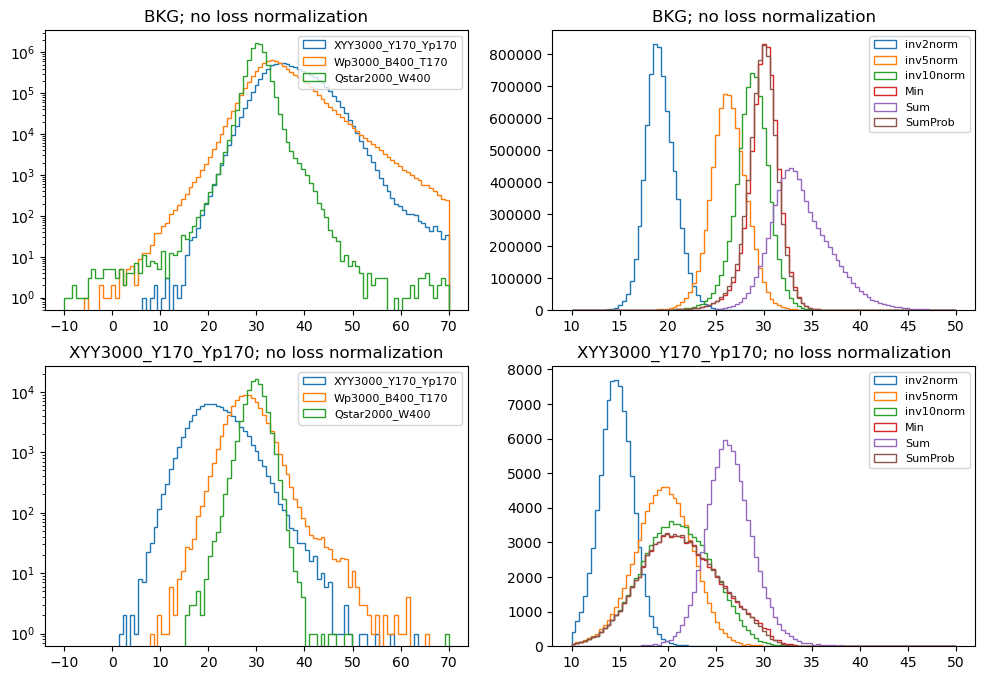

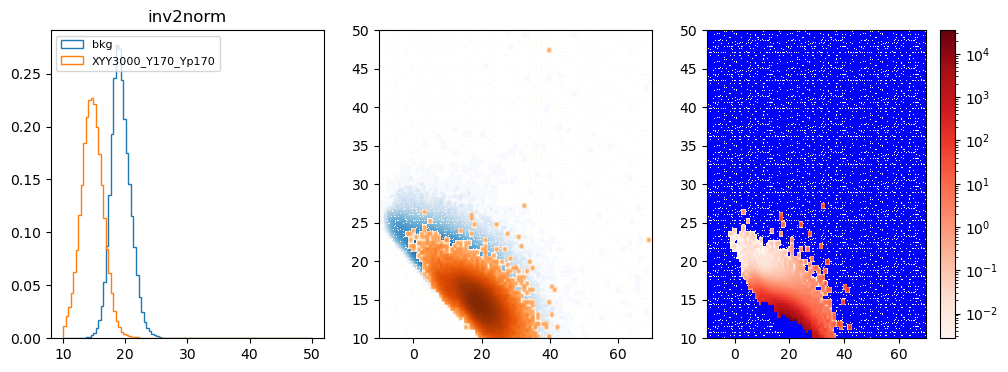

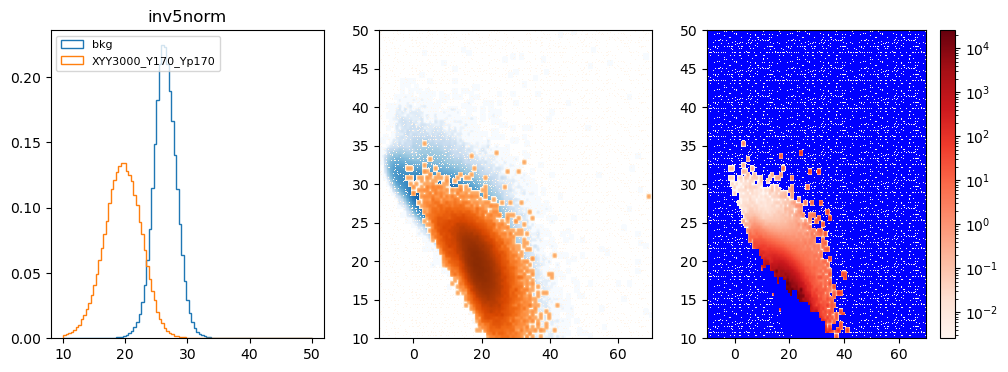

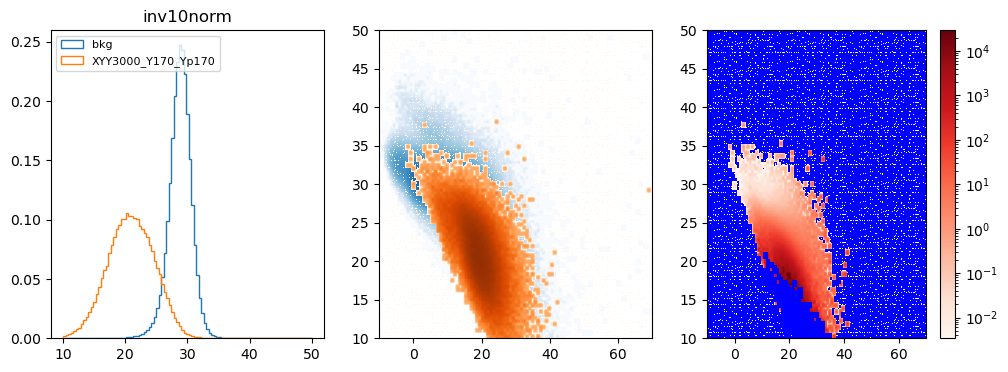

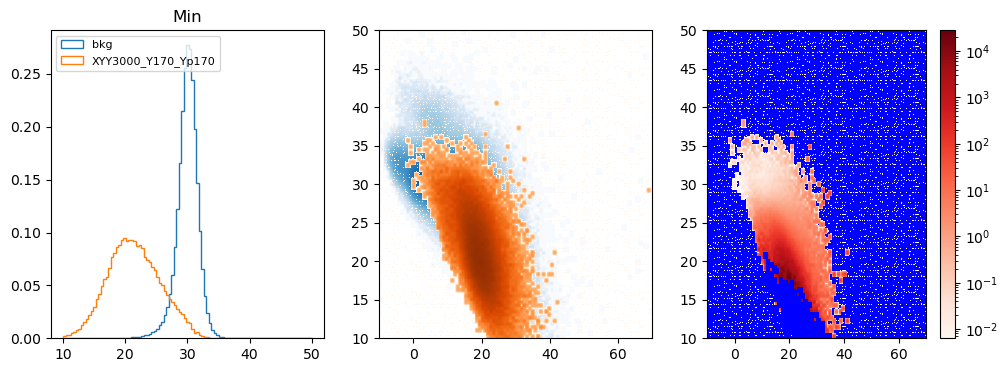

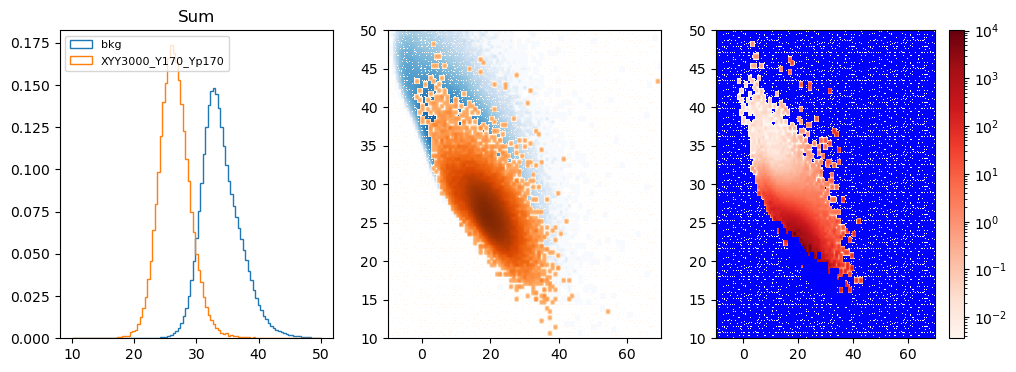

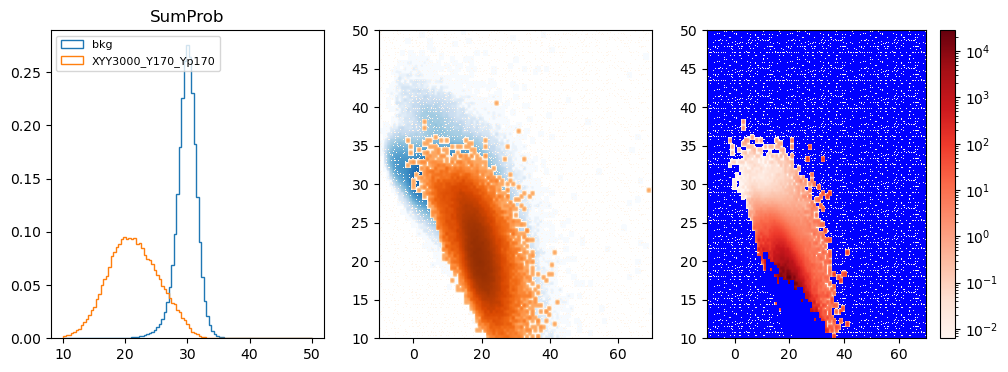

In [4]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False)

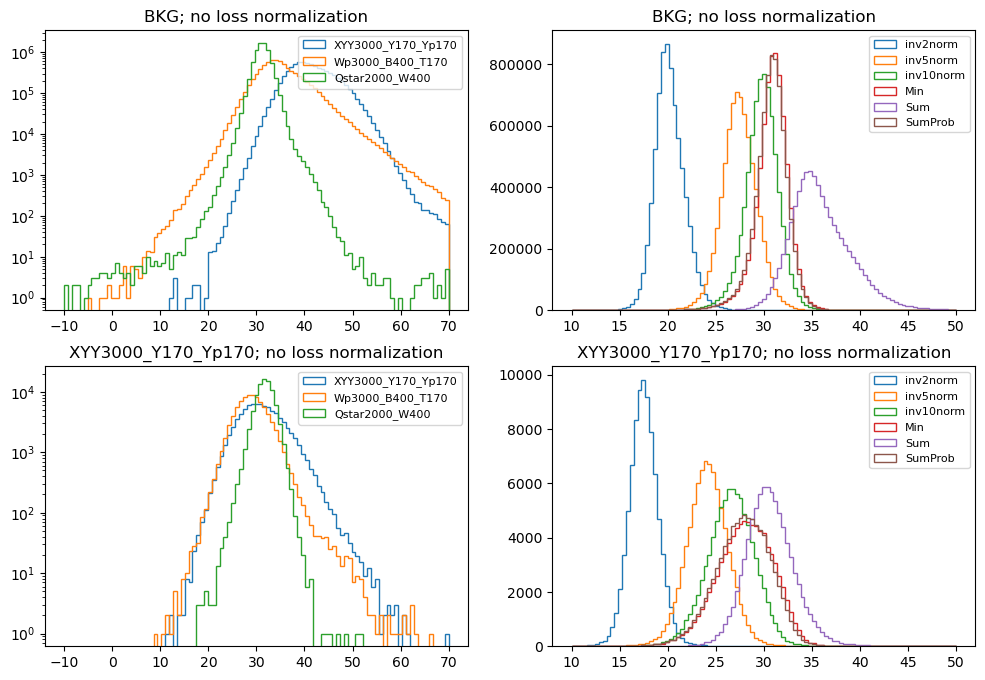

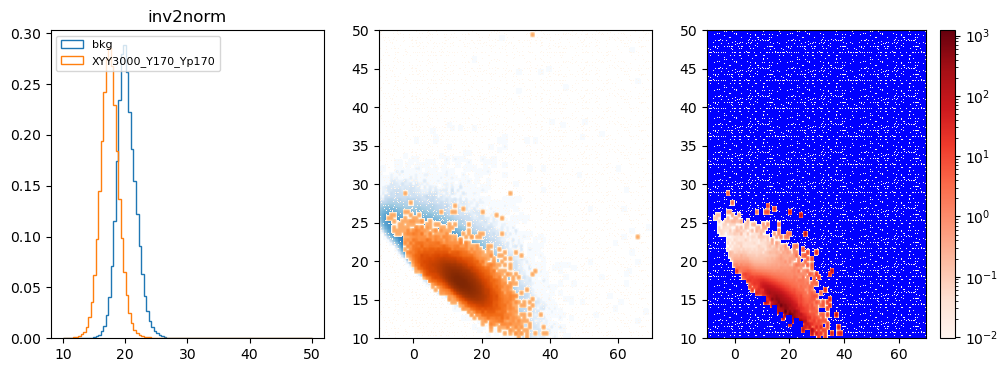

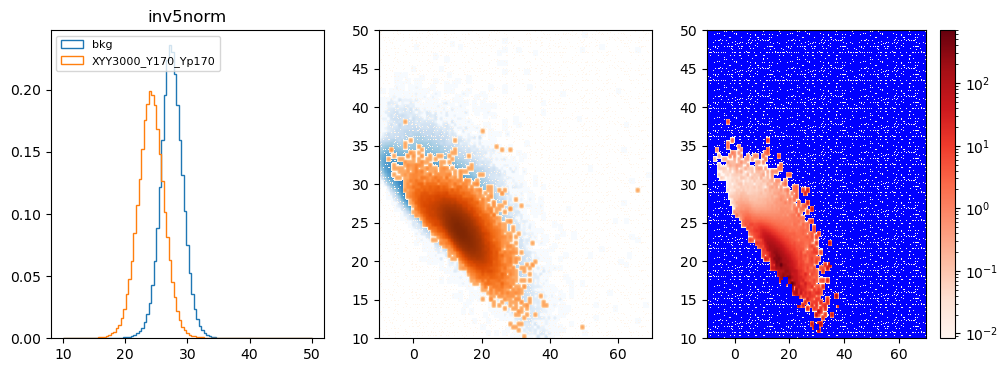

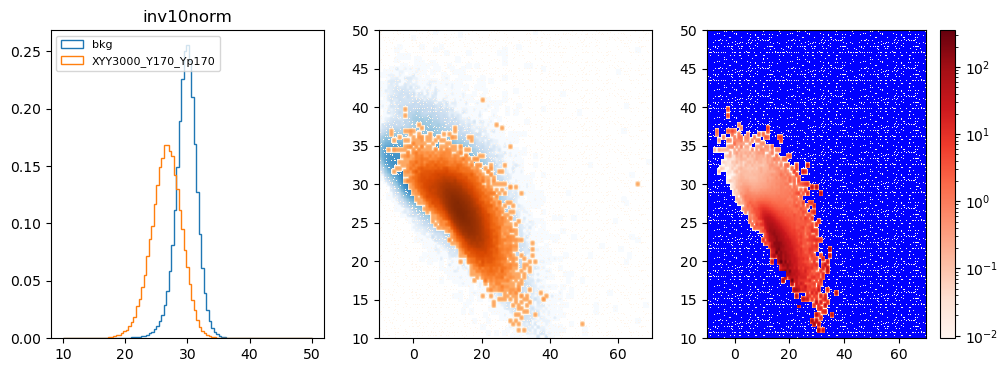

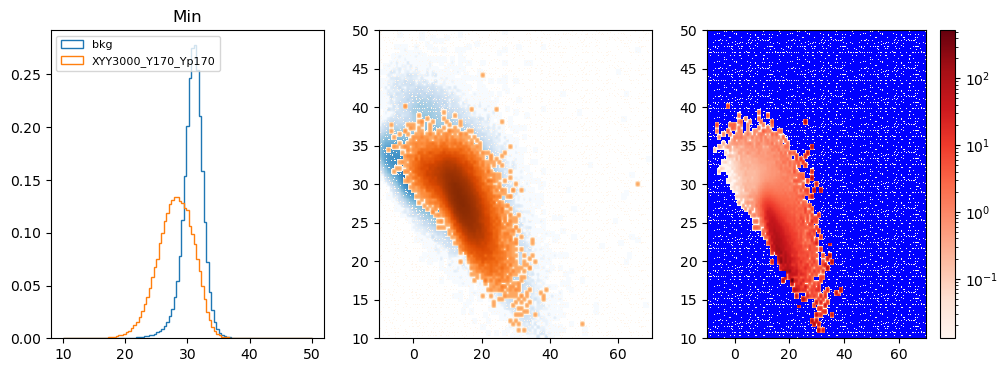

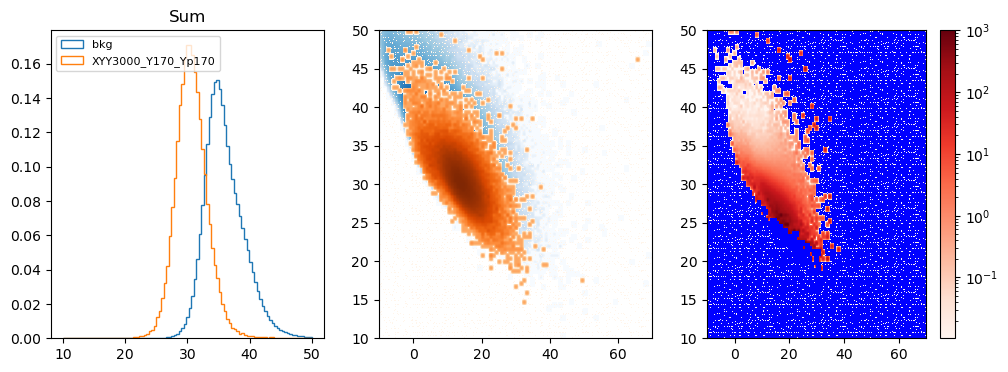

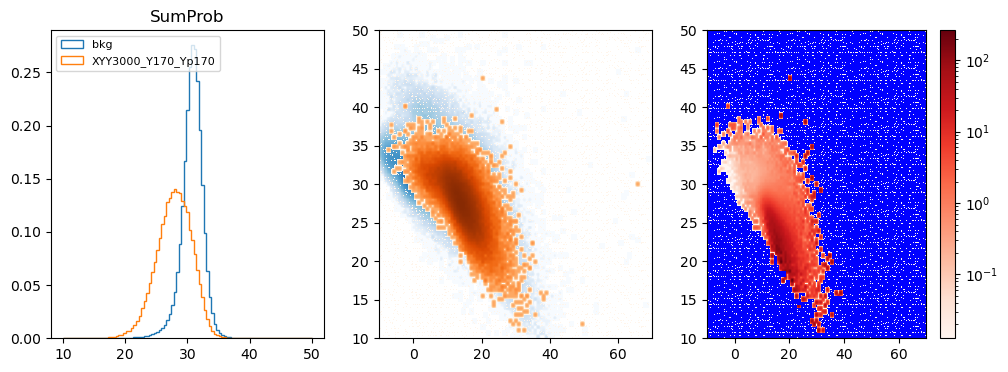

In [5]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False,decor="linear")

# No Qstar

In [6]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","Wp3000_B400_T170"]
sig = "XYY3000_Y170_Yp170"

/home/sambt/CASE_final/CASE_QUAK_final/finalTraining_nodEtaCut/quakSpaceMaker.py:29: RuntimeWarning: divide by zero encountered in log
  sumProbLoss = LossTransform(lambda x : -np.log(np.sum(np.exp(-x),axis=1)), "SumProb")


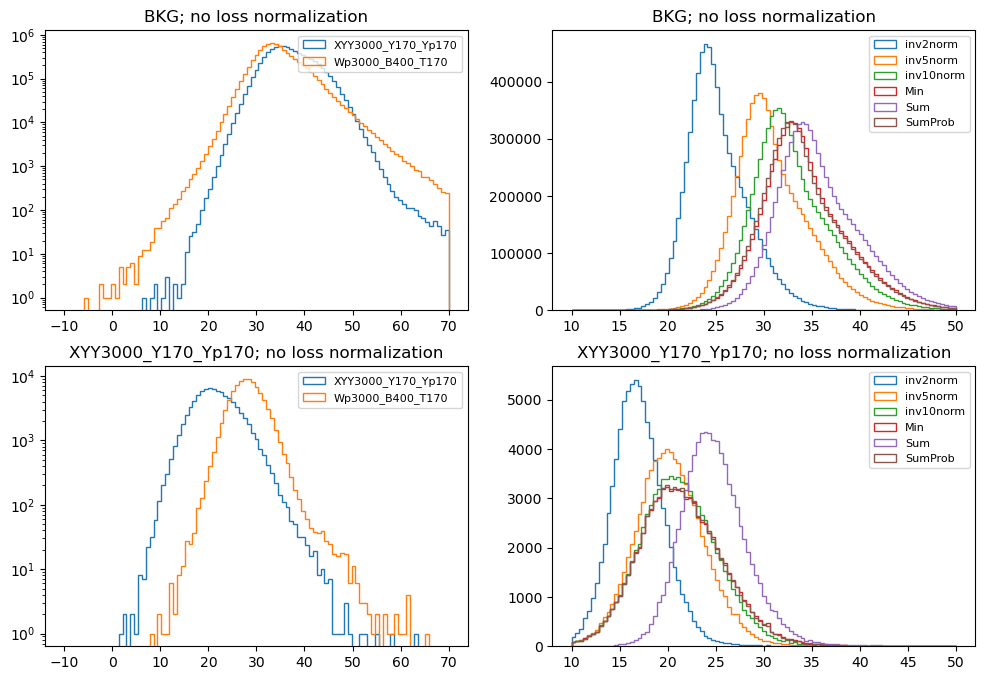

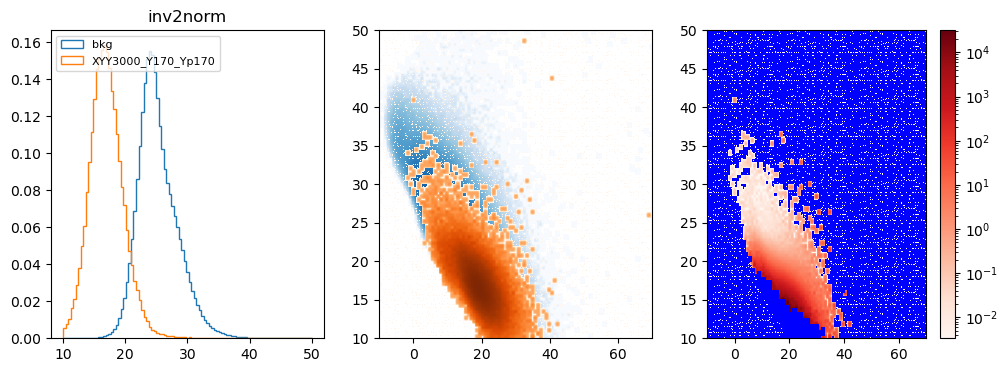

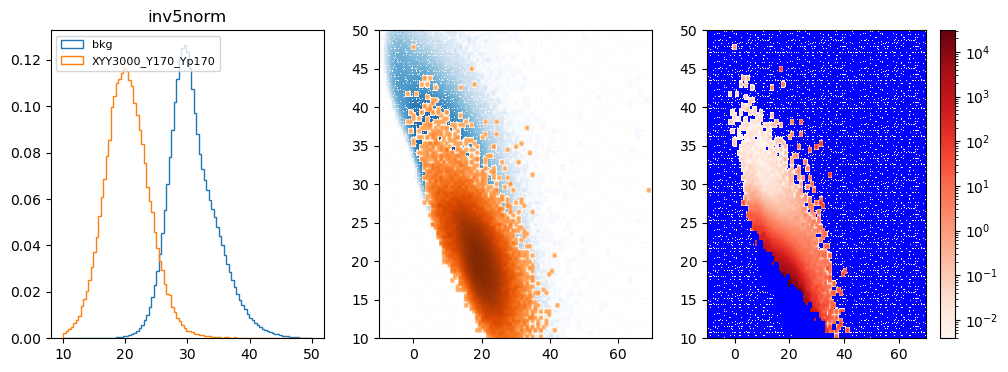

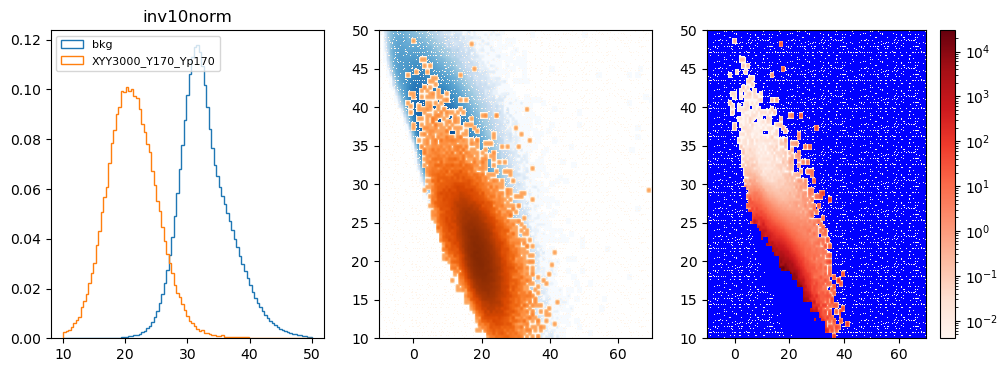

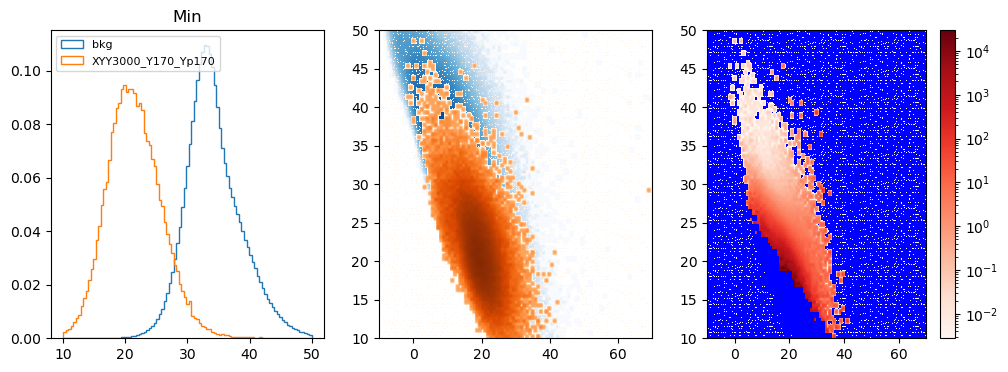

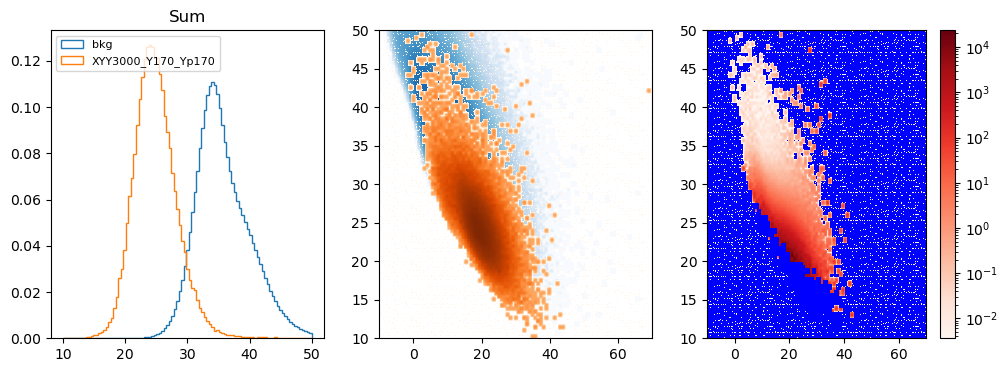

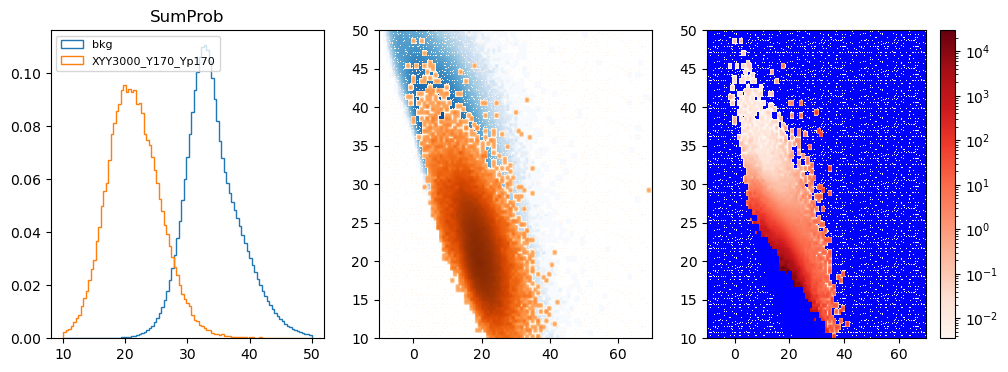

In [7]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False)

/home/sambt/CASE_final/CASE_QUAK_final/finalTraining_nodEtaCut/quakSpaceMaker.py:29: RuntimeWarning: divide by zero encountered in log
  sumProbLoss = LossTransform(lambda x : -np.log(np.sum(np.exp(-x),axis=1)), "SumProb")


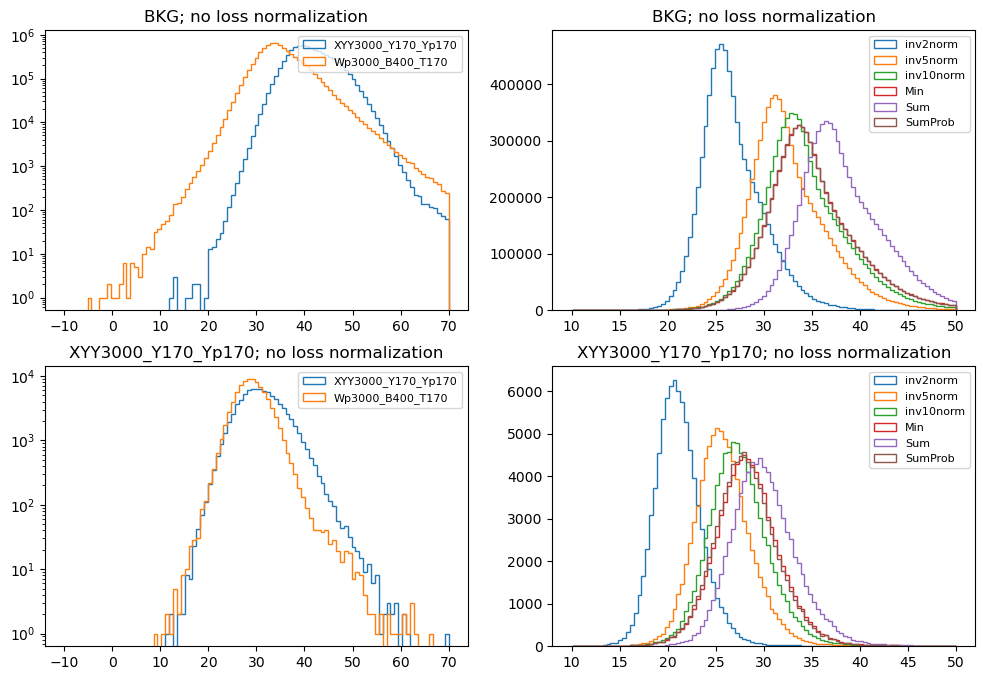

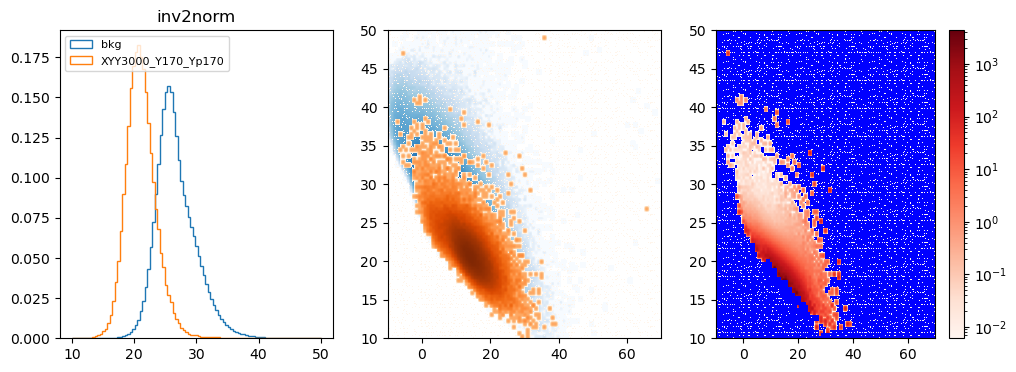

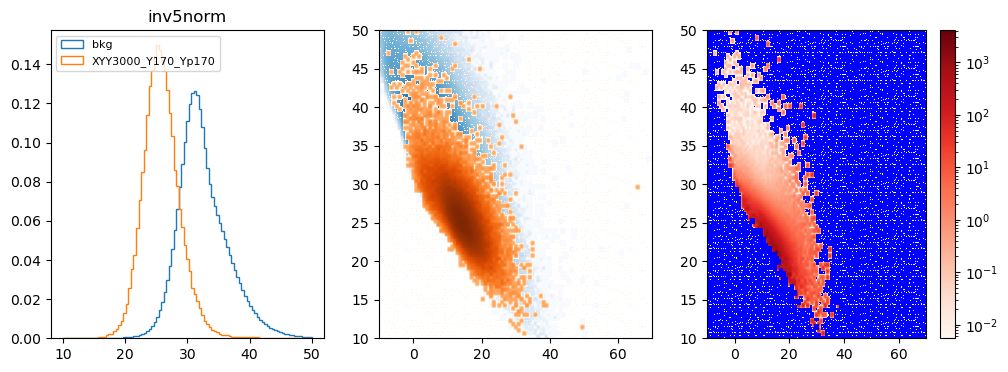

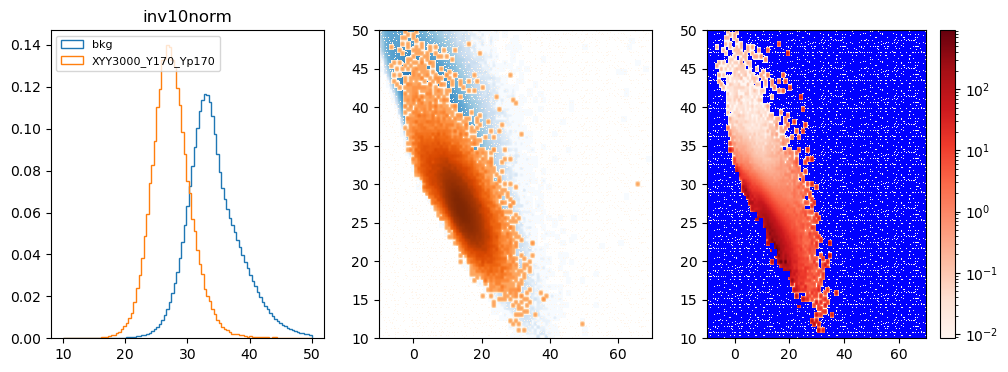

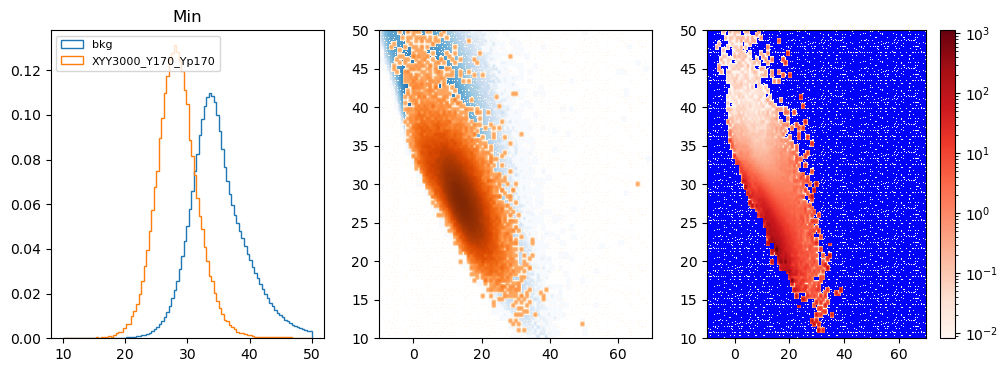

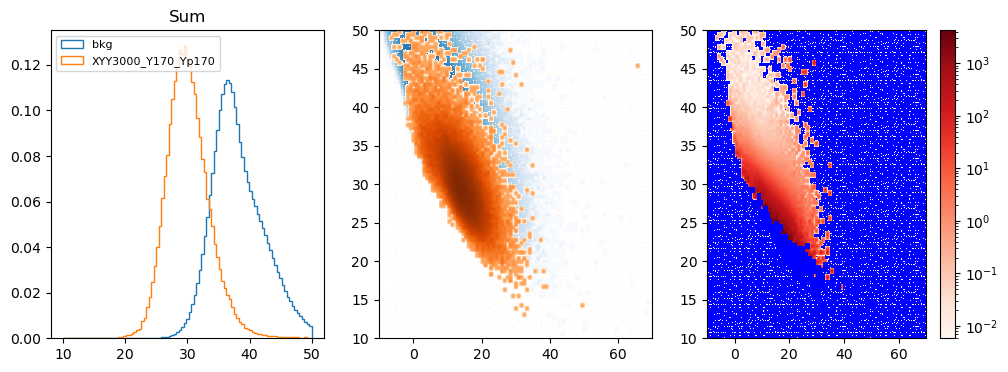

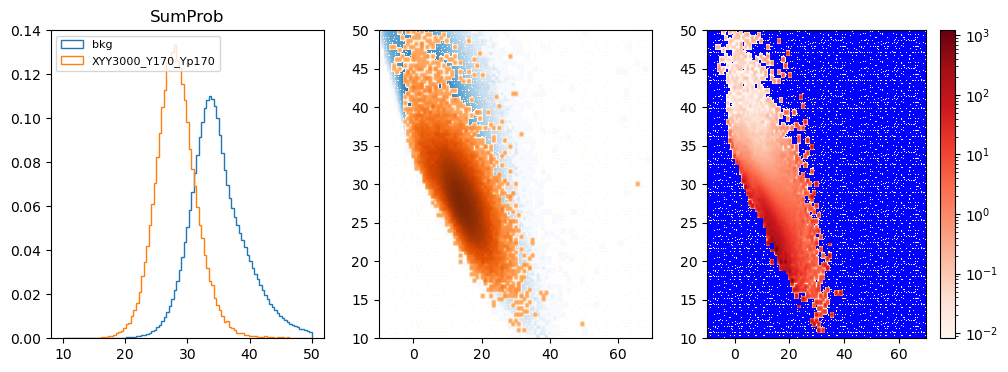

In [8]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False,decor="linear")

# No Wprime

In [9]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","Qstar2000_W400"]
sig = "XYY3000_Y170_Yp170"

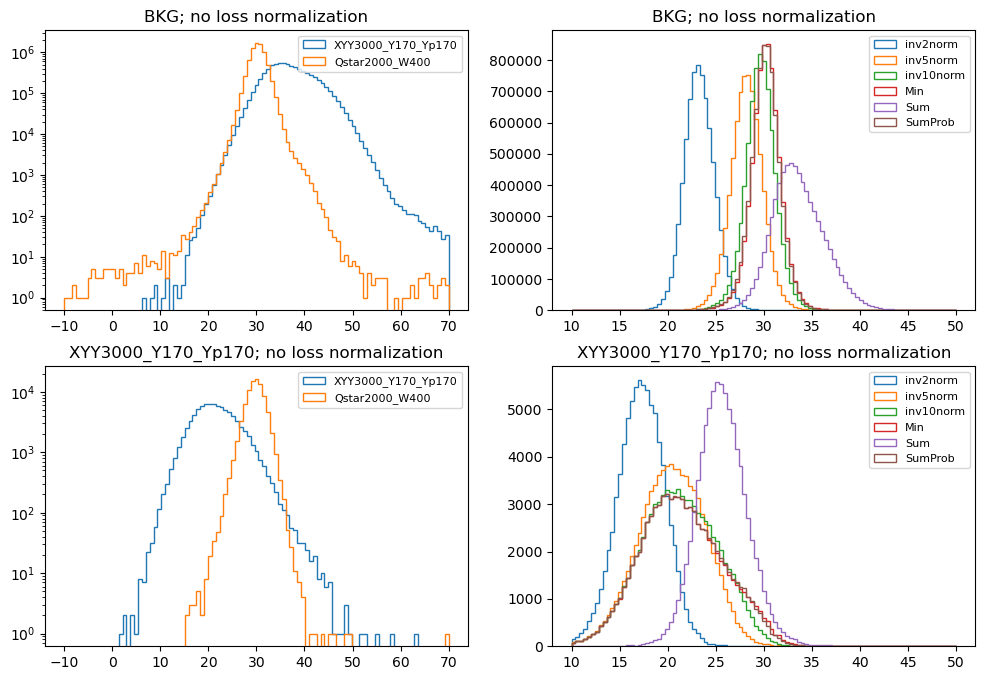

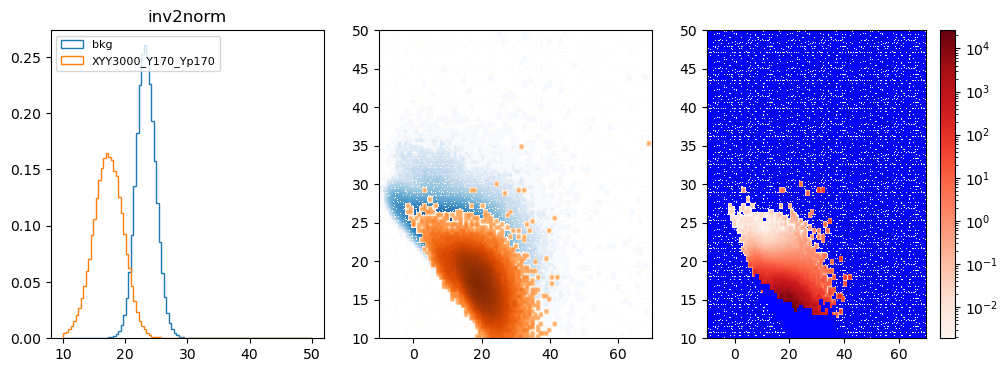

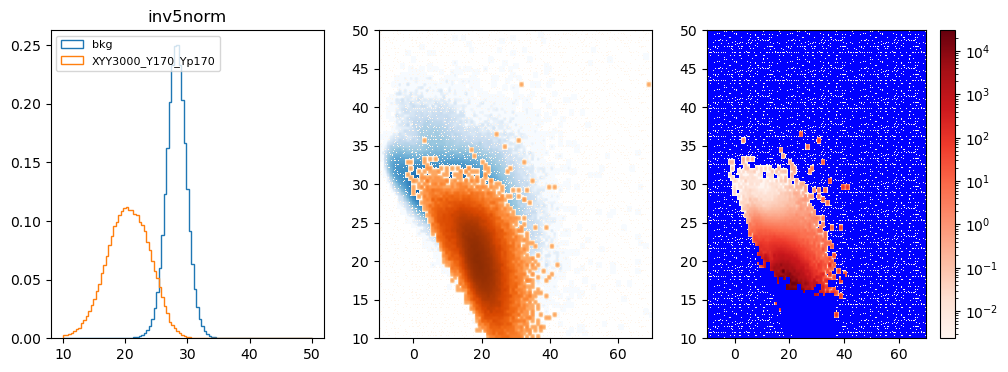

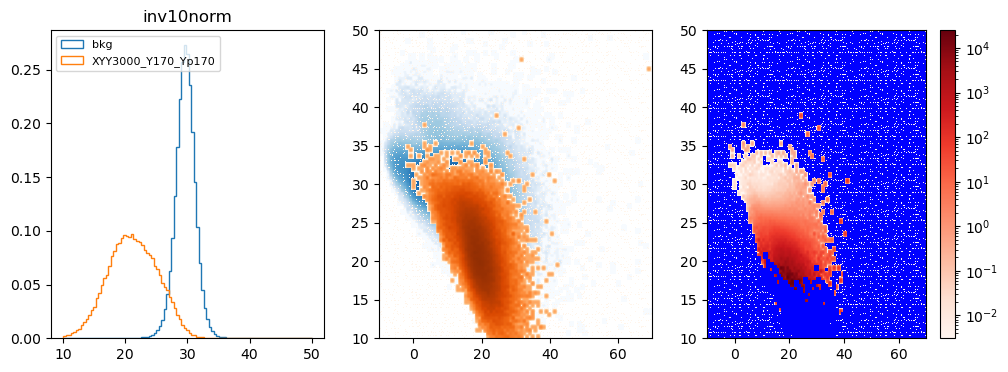

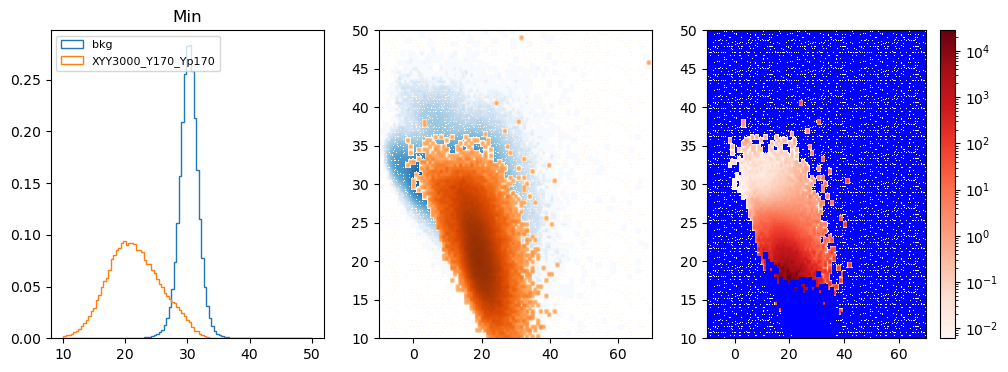

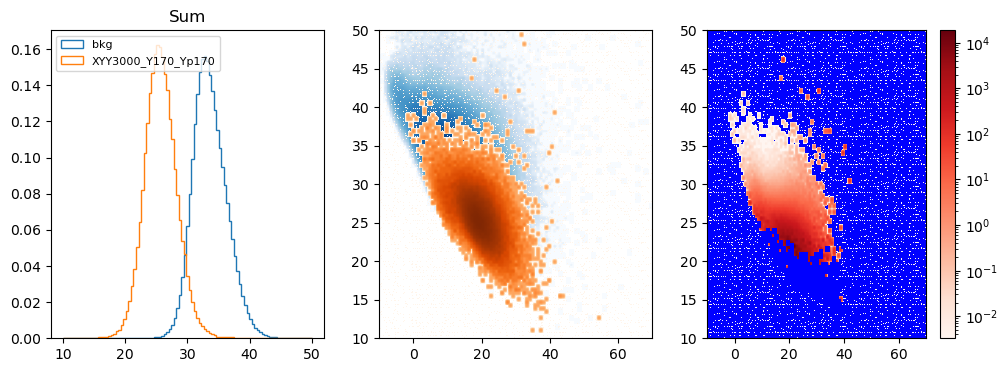

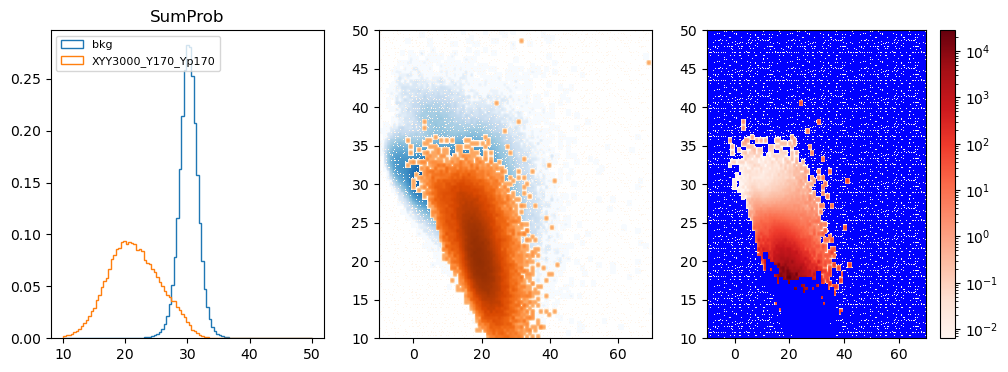

In [10]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False)

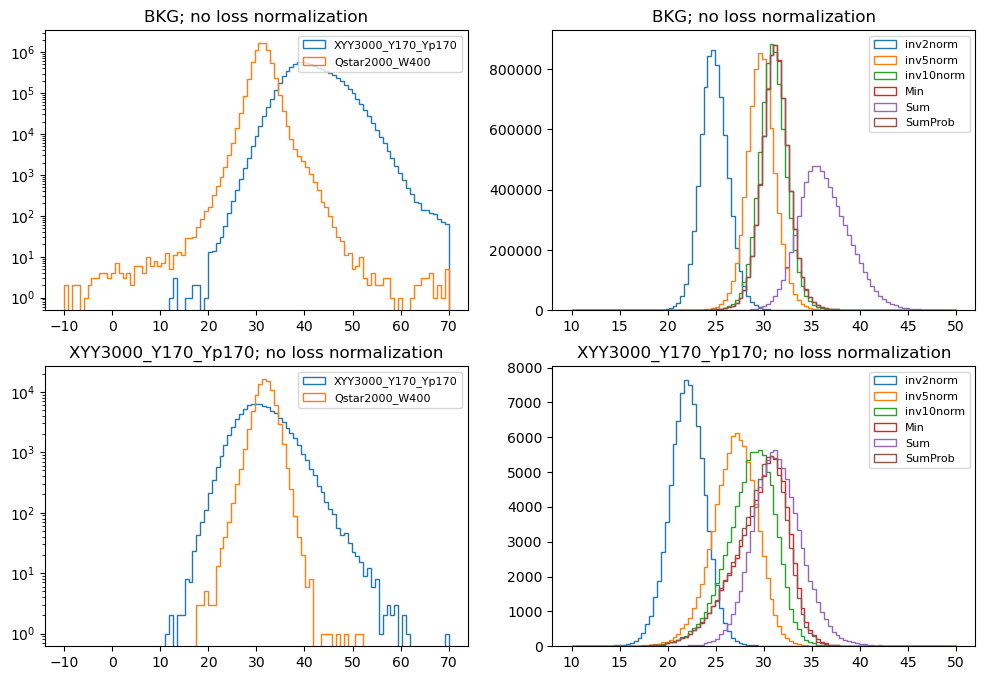

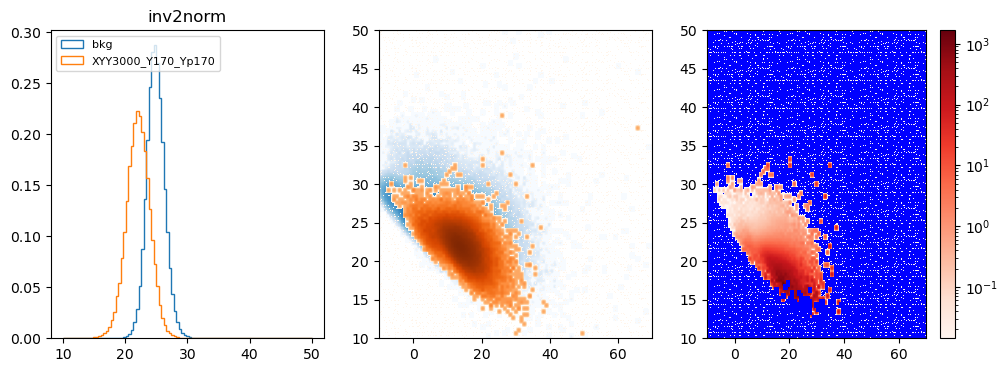

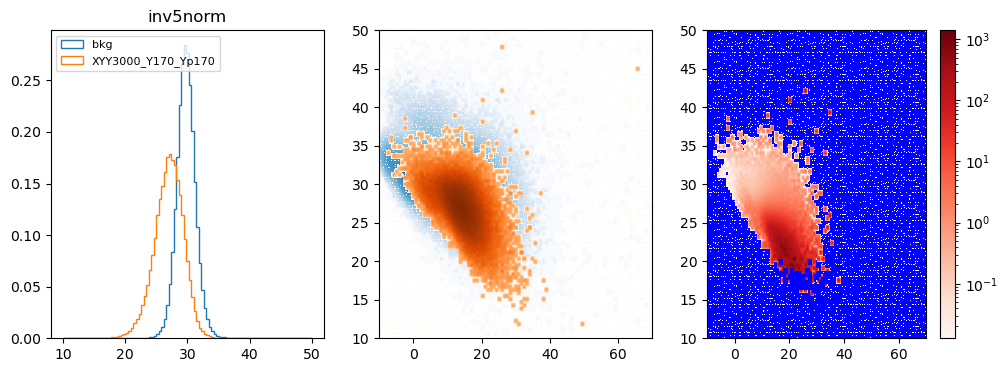

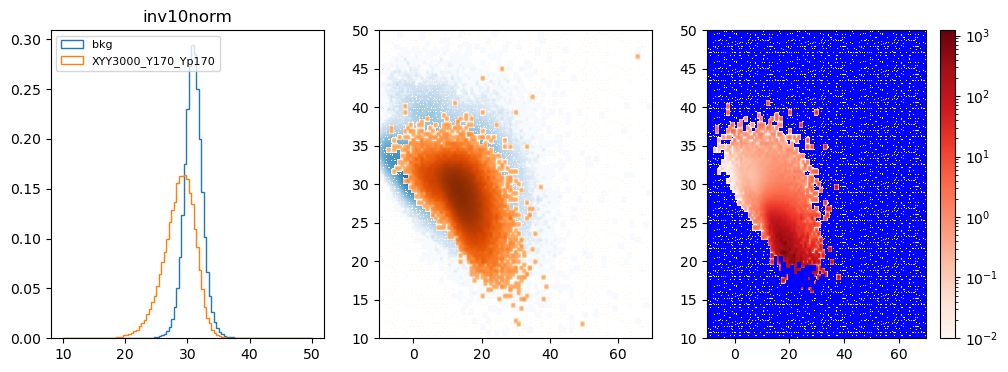

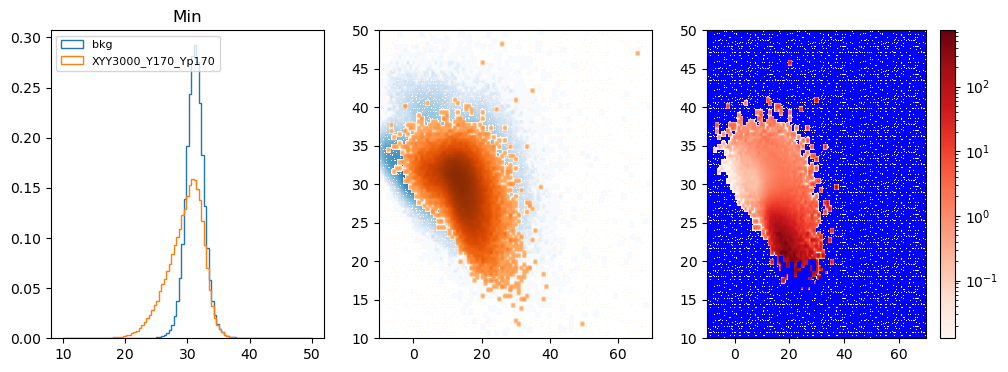

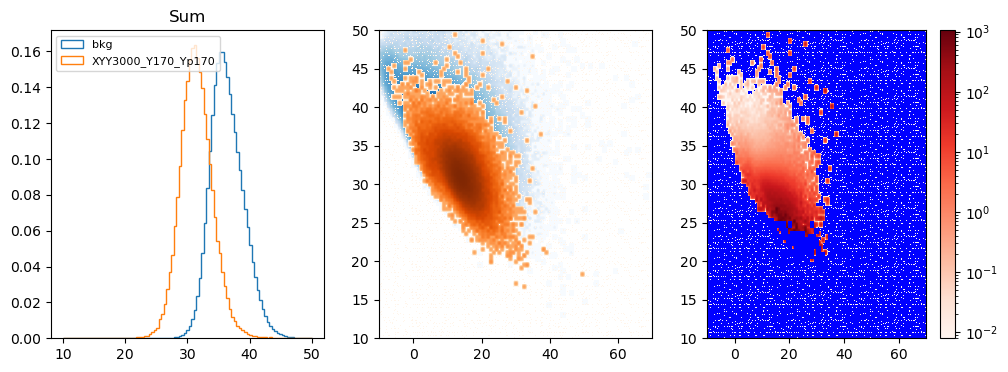

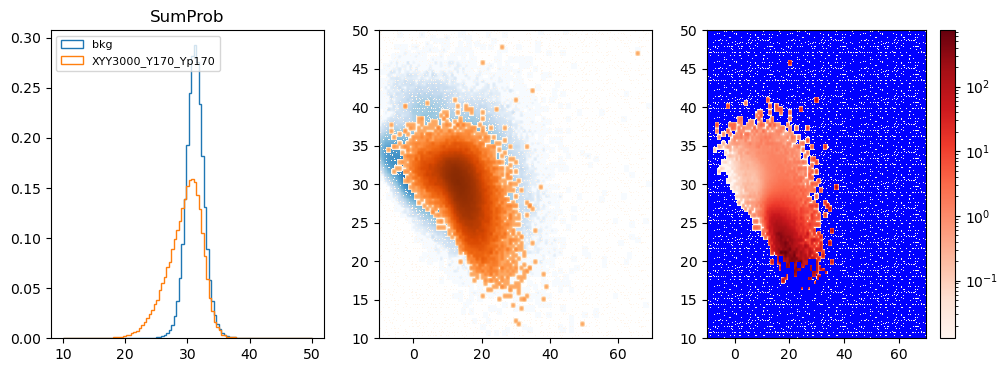

In [11]:
reducs = ['inv2norm','inv5norm','inv10norm','Min','Sum','SumProb']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False,decor="linear")

# Just XYY

In [12]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170"]
sig = "XYY3000_Y170_Yp170"

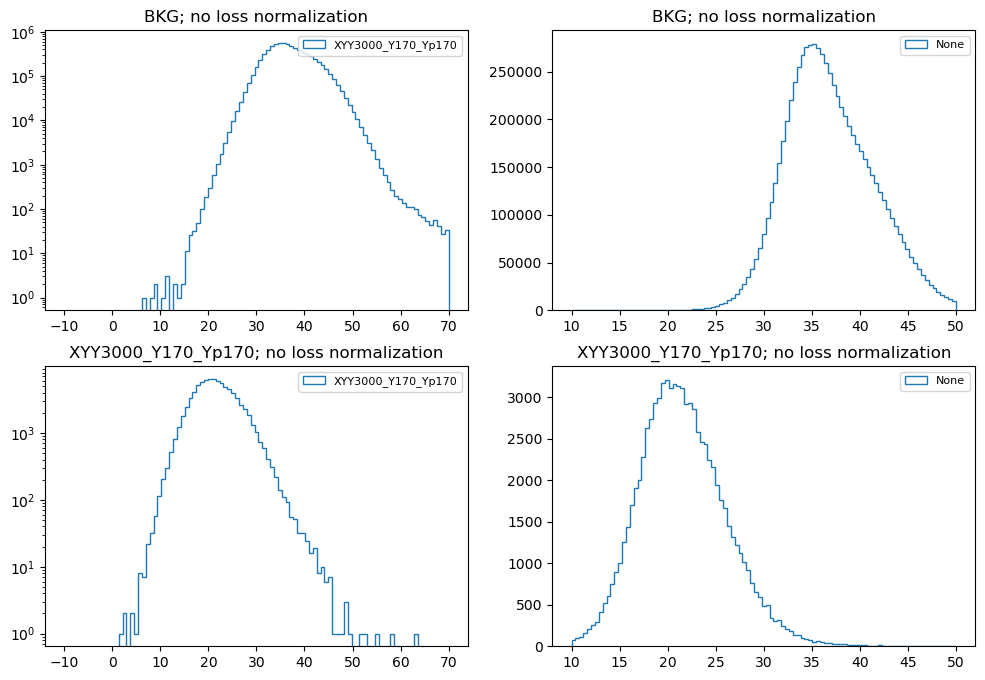

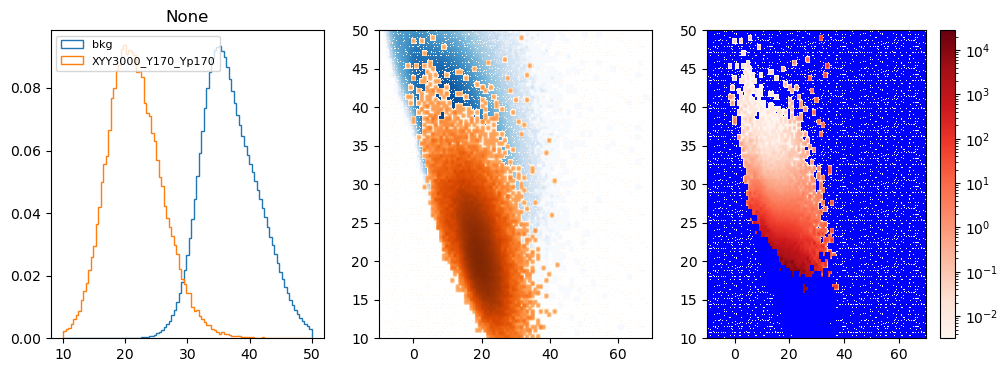

In [13]:
reducs = ['None']
make_diag_plots(bkg_axis,sig_axes,sample=sig,reducs=reducs,norm=False)

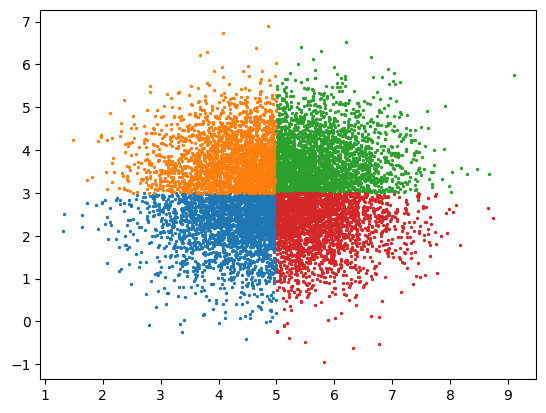

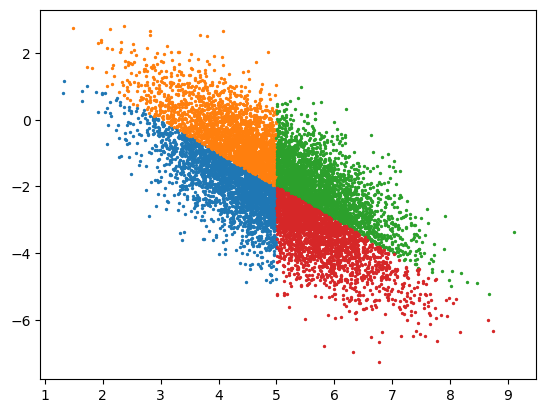

In [14]:
x = np.random.normal(loc=5,scale=1,size=10000)
y = np.random.normal(loc=3,scale=1,size=10000)
a1 = (x<5)&(y<3)
a2 = (x<5)&(y>3)
a3 = (x>5)&(y>3)
a4 = (x>5)&(y<3)
plt.figure()
plt.scatter(x[a1],y[a1],s=2)
plt.scatter(x[a2],y[a2],s=2)
plt.scatter(x[a3],y[a3],s=2)
plt.scatter(x[a4],y[a4],s=2)
plt.figure()
plt.scatter(x[a1],(y-x)[a1],s=2)
plt.scatter(x[a2],(y-x)[a2],s=2)
plt.scatter(x[a3],(y-x)[a3],s=2)
plt.scatter(x[a4],(y-x)[a4],s=2)